#  MNIST Digit Classification using CNN

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D , MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
test = pd.read_csv("../dataset/mnist_test.csv")
train = pd.read_csv("../dataset/mnist_train.csv")

In [3]:
train

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59996,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59997,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59998,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
test

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9996,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9997,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9998,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
print(train.shape)
print(test.shape)

(60000, 785)
(10000, 785)


In [6]:
train.columns

Index(['label', '1x1', '1x2', '1x3', '1x4', '1x5', '1x6', '1x7', '1x8', '1x9',
       ...
       '28x19', '28x20', '28x21', '28x22', '28x23', '28x24', '28x25', '28x26',
       '28x27', '28x28'],
      dtype='object', length=785)

In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to 28x28
dtypes: int64(785)
memory usage: 359.3 MB


In [8]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Columns: 785 entries, label to 28x28
dtypes: int64(785)
memory usage: 59.9 MB


In [9]:
train.isnull().sum().sum()

0

In [10]:
test.isnull().sum().sum()

0

In [11]:
train.duplicated().sum()

0

In [12]:
test.duplicated().sum()

0

## Class Distribution

In [14]:
train['label'].value_counts()

label
1    6742
7    6265
3    6131
2    5958
9    5949
0    5923
6    5918
8    5851
4    5842
5    5421
Name: count, dtype: int64

## Data Visualization

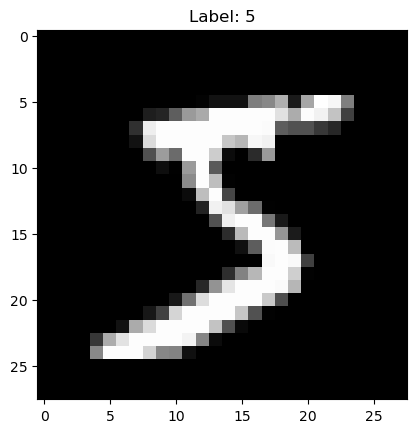

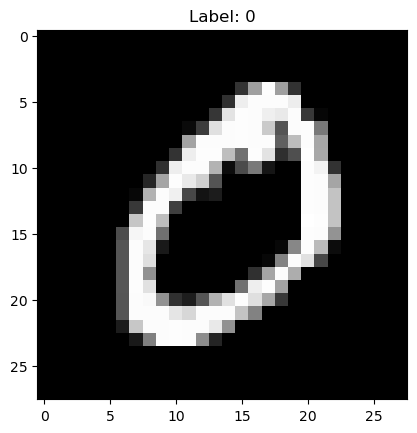

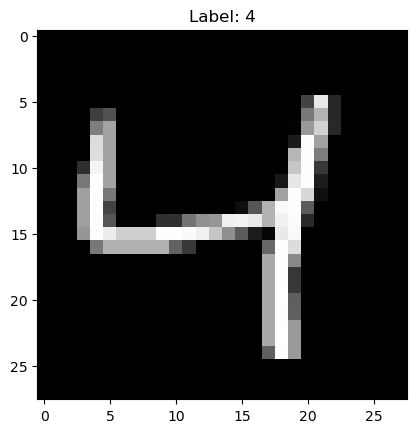

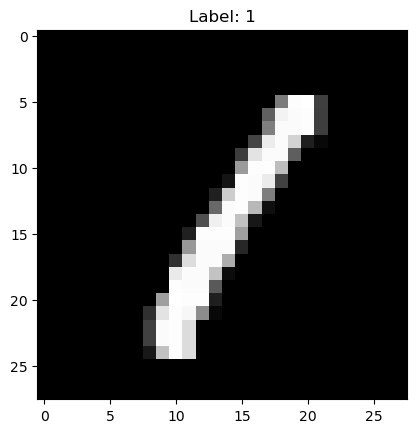

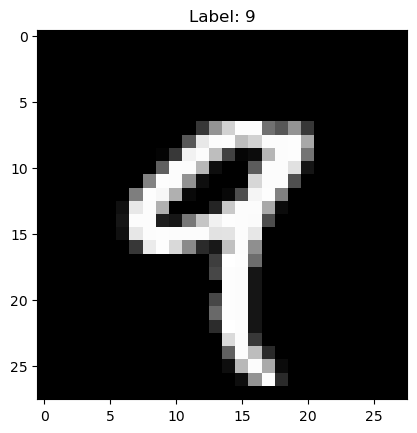

In [15]:
for i in range(5):
    plt.imshow(train.iloc[i, 1:].values.reshape(28,28), cmap='gray')
    plt.title(f"Label: {train.iloc[i, 0]}")
    plt.show()

## Prepocessing 

### Separate features and labels

In [17]:
X = train.drop('label', axis=1).values
y = train['label'].values

X_test = test.drop('label', axis=1).values
y_test = test['label'].values

### Normalize pixel values (0–255 → 0–1)  

In [19]:
X = X.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

### Normalize pixel values (0–255 → 0–1)  

In [21]:
X = X.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

### One-hot encode labels  

In [23]:
y = to_categorical(y, 10)
y_test = to_categorical(y_test, 10)

### Split into training and validation sets 

In [25]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1, random_state=42)

In [26]:
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (54000, 28, 28, 1)
X_val: (6000, 28, 28, 1)
X_test: (10000, 28, 28, 1)


In [27]:
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

y_train: (54000, 10)
y_val: (6000, 10)
y_test: (10000, 10)


## CNN Model
Build a baseline Convolutional Neural Network:
- Convolution layers for feature extraction  
- Pooling layers for dimensionality reduction  
- Dense layers for classification  

In [29]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2), 

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2), 

    Flatten(), 

    Dense(128, activation='relu'),
    Dropout(0.5), 

    Dense(10, activation='softmax')
])

In [30]:
model.compile(
    optimizer='adam', 
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)
model.summary

<bound method Model.summary of <Sequential name=sequential, built=False>>

In [31]:
# history = model.fit(
#     X_train, 
#     y_train, 
#     epochs=5, 
#     batch_size=64, 
#     validation_data=(X_val, y_val))

## Data Augmentation

In [32]:
datagen = ImageDataGenerator(
    rotation_range=10, 
    zoom_range=0.1, 
    width_shift_range=0.1, 
    height_shift_range=0.1
)
datagen.fit(X_train)

In [33]:
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=64), 
    epochs = 5, 
    validation_data=(X_val, y_val)
)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 24s 26ms/step - accuracy: 0.8549 - loss: 0.4575 - val_accuracy: 0.9788 - val_loss: 0.0687
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - accuracy: 0.9416 - loss: 0.1937 - val_accuracy: 0.9842 - val_loss: 0.0501
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.9574 - loss: 0.1439 - val_accuracy: 0.9890 - val_loss: 0.0365
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.9648 - loss: 0.1185 - val_accuracy: 0.9880 - val_loss: 0.0361
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.9684 - loss: 0.1038 - val_accuracy: 0.9898 - val_loss: 0.0351


In [34]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy: ", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9905 - loss: 0.0294
Test Accuracy:  0.9904999732971191


## Error Analysis

In [36]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [37]:
errors = np.where(y_pred_classes != y_true)[0]
print("Total Misclassified: ", len(errors))

Total Misclassified:  95


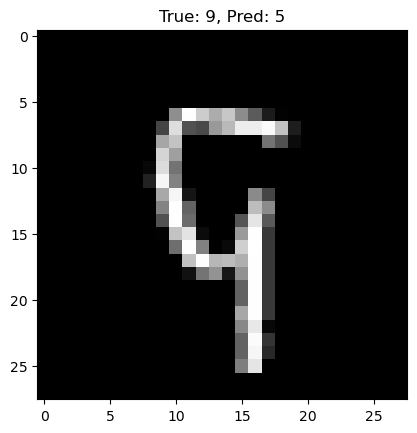

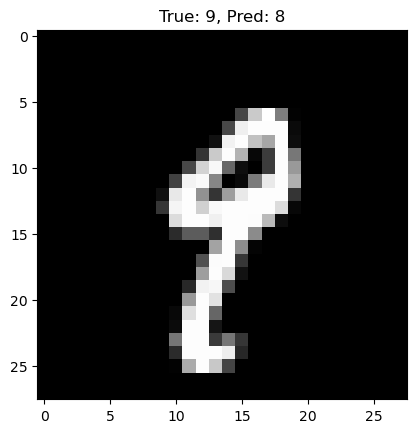

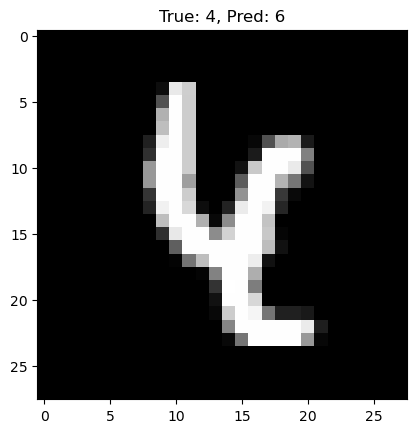

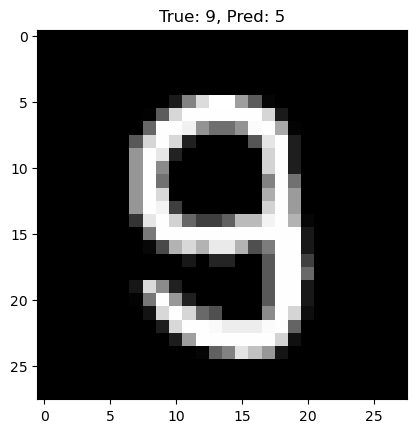

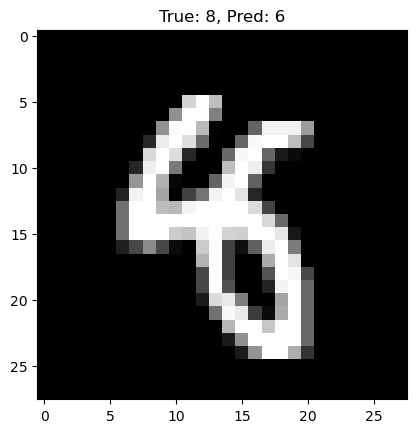

In [38]:
for i in range(5):
    idx = errors[i]
    plt.imshow(X_test[idx].reshape(28,28), cmap='gray')
    plt.title(f"True: {y_true[idx]}, Pred: {y_pred_classes[idx]}")
    plt.show()

##  Sample Predictions

In [85]:
def show_cnn_predictions(model, X_cnn, y_true, n=5):
    idxs = np.random.choice(len(X_cnn), n, replace=False)
    
    plt.figure(figsize=(12, 4))
    
    for i, idx in enumerate(idxs):
        # Image
        plt.subplot(1, n, i+1)
        plt.imshow(X_cnn[idx].reshape(28, 28), cmap="gray")
        plt.axis("off")
        
        # Prediction
        pred = np.argmax(model.predict(X_cnn[idx].reshape(1,28,28,1), verbose=0))
        true = np.argmax(y_true[idx])
        
        plt.title(f"True: {true} | Predict: {pred}")
    
    plt.tight_layout()
    plt.show()

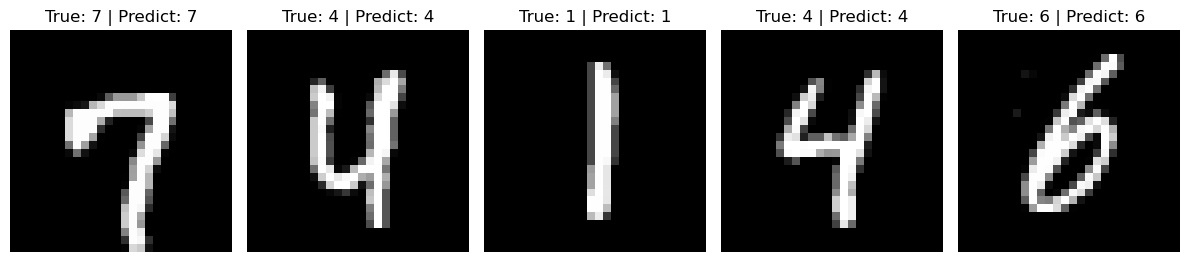

In [87]:
show_cnn_predictions(model, X_test, y_test, n=5)